# From Raw X300 IQ to LTE DL/UL PCAP

## Experiment background

This notebook analyzes an authorized, passive recording of a real-world **T-Mobile / Starlink Direct-to-Cell LTE** experiment. We used an Ettus **USRP X300 software-defined radio (SDR)** as a nearby third-party receiver. The X300 did not transmit or join the network; it just recorded the radio waveform for offline research analysis.

Two X300 receive channels started from the same hardware time:

| X300 channel | Link direction | Center frequency | LTE channel bandwidth | Recording rate |
|---|---|---:|---:|---:|
| Channel 0 | Satellite/base-station downlink (DL) | 1992.5 MHz | 5 MHz, 25 resource blocks | 10 MS/s |
| Channel 1 | Phone/UE uplink (UL) | 1912.5 MHz | 5 MHz, 25 resource blocks | 10 MS/s |

The 5 MHz value is the nominal occupied LTE channel bandwidth. The X300 stored 10 million complex I/Q samples per second on each channel, giving extra frequency space around the LTE carrier. This tutorial uses a synchronized **five-second** raw capture as an example, containing 50,000,000 aligned IQ samples per channel in little-endian `fc32` format. 

This interval was selected because it contains a compact end-to-end traffic between Base station and User Equipment (UE) on PCI 427: MIB and SIB broadcasts, RRC connection setup, identity request/response, attach signaling, authentication request/response, security-mode signaling, timing-advance commands, and many CRC-valid UL transport blocks.

The research goal is to start from these two raw waveform files and reconstruct:

- how a satellite-beam LTE cell and its PCI are identified;
- broadcast and dedicated downlink messages, including MIB and SIB information;
- the downlink DCI/RAR grants that scheduled phone transmissions;
- the corresponding uplink PUSCH bursts and CRC-valid payloads;
- a combined DL/UL packet trace (pcap files) that can be inspected in Wireshark.

This is an executable, restartable pipeline. Radio concepts are introduced when they become necessary.

The notebook performs the complete sequence:

1. validate and downsample the five-second DL and UL IQ files;
2. align and decode PCI 427, including MIB/SIB/RRC and DCI/RAR grants;
3. use those DL grants and RRC parameters to acquire and decode UL PUSCH;
4. keep CRC-valid UL transport blocks;
5. create and store the per-PCI and combined PCAP/PCAPNG files;
6. visualize the evidence at each stage.

Every expensive stage uses **generate-if-missing** behavior. A stored output is validated and reported as `SKIP`; if it is absent or incomplete, the notebook runs the checked-in decoder stage and stores the new result under `Tutorial/decoder_results/`.

The raw IQ files are never modified. Decoder outputs are ignored by Git, while the pipeline code and fixed-capture segment configuration are tracked. The patched LTEsniffer and srsRAN helper binaries are required only when a missing decoder output must be rebuilt. Figures appear inside Jupyter and are not saved as image files.

## Roadmap: raw IQ to PCAP

1. Validate the simultaneous X300 DL and UL files.
2. Downsample both complete traces from 10 MS/s to 5.76 MS/s once.
3. View a one-second processed DL/UL waterfall.
4. Search the DL for LTE synchronization, identify PCIs, and confirm MIBs.
5. Decode DL PCAPs, including SIB1 cell identity and scheduling grants.
6. Use DL DCI0/RAR grants to predict each scheduled UL time and PRB range.
7. Search timing/CFO candidates, verify PUSCH DMRS, apply RRC/UCI parameters, and test the transport-block CRC.
8. Keep only CRC-valid UL payloads and combine MIB, DL, and UL into PCAP/PCAPNG.

## 1. Import the Python libraries and find the data

The `raw_data/` directory is inside `Tutorial/`. An optional `LTE_RAW_DATA_DIR` environment variable is also supported for testing or a different directory layout.

## 1. Download the five-second teaching capture if needed

The tutorial expects `capture.json`, `downlink.fc32`, and `uplink.fc32` under
`Tutorial/raw_data`. If all three files already match the metadata, this step
prints `SKIP` and performs no network access. Otherwise it downloads the public
[Google Drive folder](https://drive.google.com/drive/folders/1wCYdKAMnfdbHNCjYmZjAuH_tyEFCWQHX?usp=sharing)
into a temporary directory, validates both synchronized IQ file sizes, and only
then moves them into `Tutorial/raw_data`.

The download is approximately 800 MB. Run `bash Tutorial/setup_ubuntu.sh` first
on a clean machine; the setup installs the `gdown` folder downloader.

In [1]:
from pathlib import Path
import importlib.util
import json
import os
import shutil
import subprocess
import sys

DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1wCYdKAMnfdbHNCjYmZjAuH_tyEFCWQHX?usp=sharing"
tutorial_candidates = (
    [Path(os.environ["LTE_TUTORIAL_DIR"])] if "LTE_TUTORIAL_DIR" in os.environ else []
) + [Path.cwd(), Path.cwd() / "Tutorial"]
DOWNLOAD_TUTORIAL_DIR = next(
    (
        path.resolve() for path in tutorial_candidates
        if (path / "utils").is_dir() and (path / "config").is_dir()
    ),
    None,
)
if DOWNLOAD_TUTORIAL_DIR is None:
    raise FileNotFoundError(
        "Cannot locate the Tutorial directory. Start Jupyter from the repository "
        "root or Tutorial directory, or set LTE_TUTORIAL_DIR."
    )

DOWNLOAD_RAW_DIR = DOWNLOAD_TUTORIAL_DIR / "raw_data"
REQUIRED_RAW_FILES = ("capture.json", "downlink.fc32", "uplink.fc32")

def validate_downloaded_capture(directory: Path):
    missing = [name for name in REQUIRED_RAW_FILES if not (directory / name).is_file()]
    if missing:
        raise FileNotFoundError(f"missing raw-data files: {missing}")
    metadata = json.loads((directory / "capture.json").read_text())
    expected_bytes = int(metadata["capture"]["sample_count_per_channel"]) * 8
    sizes = {
        name: (directory / name).stat().st_size
        for name in ("downlink.fc32", "uplink.fc32")
    }
    incorrect = {name: size for name, size in sizes.items() if size != expected_bytes}
    if incorrect:
        raise ValueError(
            f"IQ size validation failed: expected {expected_bytes:,} bytes, got {incorrect}"
        )
    return metadata, expected_bytes

try:
    downloaded_metadata, expected_raw_bytes = validate_downloaded_capture(DOWNLOAD_RAW_DIR)
    print(
        "SKIP: validated Tutorial/raw_data "
        f"({expected_raw_bytes:,} bytes per IQ channel)"
    )
except (FileNotFoundError, ValueError, KeyError, json.JSONDecodeError) as existing_error:
    if importlib.util.find_spec("gdown") is None:
        raise RuntimeError(
            "Raw data is missing or invalid and gdown is not installed. Run "
            "`bash Tutorial/setup_ubuntu.sh`, restart the kernel, and retry."
        ) from existing_error
    temporary = DOWNLOAD_TUTORIAL_DIR / ".raw_data_download"
    shutil.rmtree(temporary, ignore_errors=True)
    temporary.mkdir(parents=True)
    try:
        subprocess.run(
            [
                sys.executable, "-m", "gdown", "--folder", DRIVE_FOLDER_URL,
                "-O", str(temporary), "--remaining-ok", "--no-cookies",
            ],
            check=True,
        )
        located = {}
        for name in REQUIRED_RAW_FILES:
            matches = list(temporary.rglob(name))
            if len(matches) != 1:
                raise RuntimeError(
                    f"Expected exactly one {name} in the Drive folder; found {len(matches)}"
                )
            located[name] = matches[0]
        common_parent = located["capture.json"].parent
        if any(path.parent != common_parent for path in located.values()):
            raise RuntimeError("Downloaded raw-data files are not in one folder")
        validate_downloaded_capture(common_parent)
        DOWNLOAD_RAW_DIR.mkdir(parents=True, exist_ok=True)
        for name, source in located.items():
            source.replace(DOWNLOAD_RAW_DIR / name)
        downloaded_metadata, expected_raw_bytes = validate_downloaded_capture(DOWNLOAD_RAW_DIR)
        print(
            "CREATE: downloaded and validated Tutorial/raw_data "
            f"({expected_raw_bytes:,} bytes per IQ channel)"
        )
    finally:
        shutil.rmtree(temporary, ignore_errors=True)

SKIP: validated Tutorial/raw_data (400,000,000 bytes per IQ channel)


In [2]:
from pathlib import Path
import json
import os

import numpy as np
import matplotlib.pyplot as plt
import subprocess

plt.rcParams.update({"figure.figsize": (12, 5)})

candidates = ([Path(os.environ["LTE_RAW_DATA_DIR"])] if "LTE_RAW_DATA_DIR" in os.environ else []) + [
    Path("raw_data"),
    Path("Tutorial/raw_data"),
]
RAW_DIR = next((path.resolve() for path in candidates if path.is_dir()), None)
if RAW_DIR is None:
    raise FileNotFoundError(
        "Cannot find Tutorial/raw_data. Start Jupyter from "
        "the repository root or the Tutorial directory."
    )

META_PATH = RAW_DIR / "capture.json"
DL_PATH = RAW_DIR / "downlink.fc32"
UL_PATH = RAW_DIR / "uplink.fc32"
REPO_ROOT = RAW_DIR.parents[1]
TUTORIAL_DIR = REPO_ROOT / "Tutorial"
LOCAL_PROCESSED_DIR = (TUTORIAL_DIR / "processed_data").resolve()
LOCAL_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
SOURCE_OVERRIDE_PATH = LOCAL_PROCESSED_DIR / "source_override.json"
processed_override = (
    json.loads(SOURCE_OVERRIDE_PATH.read_text())
    if SOURCE_OVERRIDE_PATH.is_file() else {}
)
selected_processed = os.environ.get("LTE_PROCESSED_DATA_DIR") or processed_override.get("directory")
PROCESSED_DIR = Path(selected_processed or LOCAL_PROCESSED_DIR).expanduser().resolve()
DL_PROCESSED_PATH = PROCESSED_DIR / processed_override.get(
    "downlink_file", "downlink_5p76Msps.fc32"
)
UL_PROCESSED_PATH = PROCESSED_DIR / processed_override.get(
    "uplink_file", "uplink_5p76Msps.fc32"
)

metadata = json.loads(META_PATH.read_text())
capture = metadata["capture"]
print("Raw data directory:", RAW_DIR)
print(json.dumps(metadata, indent=2))

Raw data directory: /media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/raw_data
{
  "format": {
    "datatype": "fc32",
    "endianness": "little",
    "layout": "separate_files_sample_aligned",
    "channels": 2,
    "channel_0": "downlink",
    "channel_1": "uplink"
  },
  "capture": {
    "status": "complete_excerpt",
    "dl_file": "downlink.fc32",
    "ul_file": "uplink.fc32",
    "dl_frequency_hz": 1992500000,
    "ul_frequency_hz": 1912500000,
    "sample_rate_hz": 10000000,
    "bandwidth_hz_ch0": 40000000,
    "bandwidth_hz_ch1": 120000000,
    "gain_db_ch0": 35,
    "gain_db_ch1": 15,
    "sample_count_per_channel": 50000000,
    "duration_seconds": 5.0,
    "first_device_time_seconds": 4.25,
    "last_device_time_seconds": 9.2499999,
    "layout": "separate little-endian fc32 files; sample n is simultaneous across files"
  },
  "capture_utc": "20260805T014626Z",
  "excerpt": {
    "source_capture": "20260805T014622Z_1992p5_1912p5_5MHz_150s_15db_gps",
    "source_start_sec

## 2. What is an IQ sample?

The X300 does not directly store packets. It stores measurements of the radio waveform.

Each measurement contains two numbers:

- **I**: the real part of the sample;
- **Q**: the imaginary part of the sample.

Python writes one sample as:

```python
sample = I + 1j * Q
```

The file type is `fc32`: I and Q are each 32-bit floating-point numbers. One complex sample therefore occupies 8 bytes.

The downlink and uplink files started at the same hardware time. Sample number `n` in the DL file occurred at the same time as sample number `n` in the UL file. We need to preserve this relationship later when matching a downlink scheduling message with the corresponding uplink transmission.

In [3]:
FC32 = np.dtype("<c8")       # little-endian complex64: float32 I + float32 Q
BYTES_PER_SAMPLE = FC32.itemsize
INPUT_RATE_HZ = int(capture["sample_rate_hz"])
EXPECTED_SAMPLES = int(capture["sample_count_per_channel"])

def describe_file(path: Path) -> dict:
    byte_count = path.stat().st_size
    if byte_count % BYTES_PER_SAMPLE:
        raise ValueError(f"{path.name} does not contain complete fc32 samples")
    sample_count = byte_count // BYTES_PER_SAMPLE
    return {
        "name": path.name,
        "size_GB": byte_count / 1e9,
        "samples": sample_count,
        "duration_seconds": sample_count / INPUT_RATE_HZ,
    }

dl_info = describe_file(DL_PATH)
ul_info = describe_file(UL_PATH)
print(dl_info)
print(ul_info)

assert dl_info["samples"] == ul_info["samples"]
assert dl_info["samples"] == EXPECTED_SAMPLES
print(f"\nBoth channels are aligned and contain {dl_info['duration_seconds']:.3f} seconds.")

{'name': 'downlink.fc32', 'size_GB': 0.4, 'samples': 50000000, 'duration_seconds': 5.0}
{'name': 'uplink.fc32', 'size_GB': 0.4, 'samples': 50000000, 'duration_seconds': 5.0}

Both channels are aligned and contain 5.000 seconds.


## 3. Open the five-second IQ files efficiently

Each raw channel contains 50,000,000 complex samples. At 8 bytes per `fc32` sample, that is 400 MB per file (about 381 MiB), or 800 MB for the synchronized DL/UL pair. These files fit on a typical workstation, but loading both would still allocate about 800 MB of RAM before any processing begins.

`np.memmap` exposes each file as a NumPy array without copying the entire file into memory. The operating system reads only the pages needed for the requested slice, which keeps the same code practical for both this five-second teaching capture and longer recordings.

In [4]:
dl_iq = np.memmap(DL_PATH, dtype=FC32, mode="r")
ul_iq = np.memmap(UL_PATH, dtype=FC32, mode="r")

print("DL array shape:", dl_iq.shape)
print("UL array shape:", ul_iq.shape)
print("First five DL samples:", dl_iq[:5])
print("First five UL samples:", ul_iq[:5])

DL array shape: (50000000,)
UL array shape: (50000000,)
First five DL samples: [-0.00134281-0.00119022j -0.0004883 -0.00021363j  0.00100711-0.00106815j
 -0.00112918-0.00167852j -0.00103763+0.00054933j]
First five UL samples: [9.1555528e-05+9.1555528e-05j 0.0000000e+00+1.5259255e-04j
 1.5259255e-04+1.5259255e-04j 1.5259255e-04+9.1555528e-05j
 1.8311106e-04+0.0000000e+00j]


## 4. Create the continuous 5.76 MS/s decoder inputs once

The 5 MHz LTE decoder expects 5.76 million samples per second, so the cell below
resamples each five-second, 10 MS/s channel by the exact ratio 72/125. The result
is approximately 28.8 million complex samples, or 230.4 MB, per processed channel.

The synchronized DL and UL channels pass through one continuous, identical
rational-resampler chain. Processing independent time blocks could introduce
filter-state and phase discontinuities that break LTE synchronization even when
the final sample count looks correct.

The repository setup installs GNU Radio. This cell uses its streaming rational
resampler for both channels in one flowgraph. A versioned manifest distinguishes
the continuous output from older blockwise files. Valid existing outputs print
`SKIP`; otherwise temporary outputs are validated and then atomically moved into
`Tutorial/processed_data`.

In [5]:
DECODER_RATE_HZ = 5_760_000
NOMINAL_DECODER_SAMPLES = EXPECTED_SAMPLES * DECODER_RATE_HZ // INPUT_RATE_HZ
PROCESSING_MANIFEST = (
    SOURCE_OVERRIDE_PATH if processed_override else PROCESSED_DIR / "processing.json"
)
RESAMPLER = TUTORIAL_DIR / "utils" / "decoder_core" / "scripts" / "channelize_pair.py"

def continuous_pair_is_complete() -> bool:
    if not all(path.is_file() for path in (
        DL_PROCESSED_PATH, UL_PROCESSED_PATH, PROCESSING_MANIFEST
    )):
        return False
    try:
        saved = json.loads(PROCESSING_MANIFEST.read_text())
    except (OSError, json.JSONDecodeError):
        return False
    dl_samples = DL_PROCESSED_PATH.stat().st_size // BYTES_PER_SAMPLE
    ul_samples = UL_PROCESSED_PATH.stat().st_size // BYTES_PER_SAMPLE
    return (
        saved.get("method") == "gnuradio.rational_resampler_ccc"
        and saved.get("input_sample_rate_hz") == INPUT_RATE_HZ
        and saved.get("output_sample_rate_hz") == DECODER_RATE_HZ
        and dl_samples == ul_samples
        and abs(dl_samples - NOMINAL_DECODER_SAMPLES) <= 256
    )

if continuous_pair_is_complete():
    print("SKIP: validated continuous 5.76 MS/s DL/UL pair")
else:
    if processed_override:
        raise RuntimeError(
            f"The processed-IQ override is incomplete or invalid: {SOURCE_OVERRIDE_PATH}"
        )
    gnuradio_check = subprocess.run(
        ["/usr/bin/python3", "-c", "import gnuradio"], check=False
    )
    if gnuradio_check.returncode:
        raise RuntimeError(
            "GNU Radio is missing. From the repository root run "
            "`bash Tutorial/setup_ubuntu.sh`, restart the kernel, and retry."
        )
    dl_partial = DL_PROCESSED_PATH.with_suffix(".fc32.partial")
    ul_partial = UL_PROCESSED_PATH.with_suffix(".fc32.partial")
    manifest_partial = PROCESSED_DIR / "processing.partial.json"
    for partial in (dl_partial, ul_partial, manifest_partial):
        partial.unlink(missing_ok=True)
    subprocess.run([
        "/usr/bin/python3", str(RESAMPLER), "--manifest", str(META_PATH),
        "--dl-output", str(dl_partial), "--ul-output", str(ul_partial),
        "--output-rate", str(DECODER_RATE_HZ), "--result", str(manifest_partial),
    ], check=True)
    dl_samples = dl_partial.stat().st_size // BYTES_PER_SAMPLE
    ul_samples = ul_partial.stat().st_size // BYTES_PER_SAMPLE
    if dl_samples != ul_samples or abs(dl_samples - NOMINAL_DECODER_SAMPLES) > 256:
        raise RuntimeError(
            f"Invalid continuous resampler output: DL={dl_samples:,}, UL={ul_samples:,}"
        )
    dl_partial.replace(DL_PROCESSED_PATH)
    ul_partial.replace(UL_PROCESSED_PATH)
    processing = json.loads(manifest_partial.read_text())
    processing.update({
        "source_samples_per_channel": EXPECTED_SAMPLES,
        "processed_samples_per_channel": dl_samples,
        "downlink_file": DL_PROCESSED_PATH.name,
        "uplink_file": UL_PROCESSED_PATH.name,
    })
    PROCESSING_MANIFEST.write_text(json.dumps(processing, indent=2) + "\n")
    manifest_partial.unlink(missing_ok=True)
    print(f"CREATE: {dl_samples:,} continuous samples per channel")

processing = json.loads(PROCESSING_MANIFEST.read_text())
EXPECTED_DECODER_SAMPLES = int(processing["processed_samples_per_channel"])
print("Processed data directory:", PROCESSED_DIR)
print(json.dumps(processing, indent=2))

SKIP: validated continuous 5.76 MS/s DL/UL pair
Processed data directory: /media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/processed_data
{
  "method": "gnuradio.rational_resampler_ccc",
  "source_manifest": "/media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/raw_data/capture.json",
  "input_sample_rate_hz": 10000000,
  "output_sample_rate_hz": 5760000,
  "dl_output": "/media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/processed_data/downlink_5p76Msps.fc32.partial",
  "ul_output": "/media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/processed_data/uplink_5p76Msps.fc32.partial",
  "samples_per_channel": 28799934,
  "bytes_per_file": 230399472,
  "end_of_stream_samples_trimmed": 0,
  "alignment": "identical rational ratio, taps, and group delay were applied to both channels in one flowgraph",
  "source_samples_per_channel": 50000000,
  "processed_samples_per_channel": 28799934,
  "downlink_file": "downlink_5p76Msps.fc32",
  "uplink_file": "uplink_5p76Msps.fc32"
}


## 5. Open the processed DL and UL files

These memory-mapped arrays cover the complete five-second teaching capture at the decoder's 5.76 MS/s input rate. Each processed file is about 230.4 MB, and opening it does not copy all samples into RAM.

The resampler preserves channel alignment: sample `n` in processed DL corresponds to sample `n` in processed UL.

In [6]:
decoder_dl = np.memmap(DL_PROCESSED_PATH, dtype=FC32, mode="r")
decoder_ul = np.memmap(UL_PROCESSED_PATH, dtype=FC32, mode="r")

print("Processed DL shape:", decoder_dl.shape)
print("Processed UL shape:", decoder_ul.shape)
assert decoder_dl.size == decoder_ul.size == EXPECTED_DECODER_SAMPLES

Processed DL shape: (28799934,)
Processed UL shape: (28799934,)


## 6. Display one second of processed downlink and uplink spectrum

A normal line plot is not very helpful for millions of radio samples. Instead, we repeatedly calculate a short frequency spectrum and stack the results vertically. This is called a **waterfall**:

- the horizontal axis is frequency;
- the vertical axis is time;
- brighter colors mean stronger received signals.

The plot uses one second from the five-second capture rather than loading or transforming the whole file. It samples 500 short FFT windows from the memory-mapped processed channels, keeping the visualization fast and memory-efficient.

In an urban area, the 1992.5 MHz satellite downlink is not observed in isolation. Strong terrestrial T-Mobile transmissions in the same or nearby PCS spectrum can overlap the receiver's displayed downlink span. This raises the interference floor behind the weaker direct-to-cell satellite signal, reduces its effective signal-to-interference-plus-noise ratio (SINR), and can make synchronization and packet decoding less reliable.

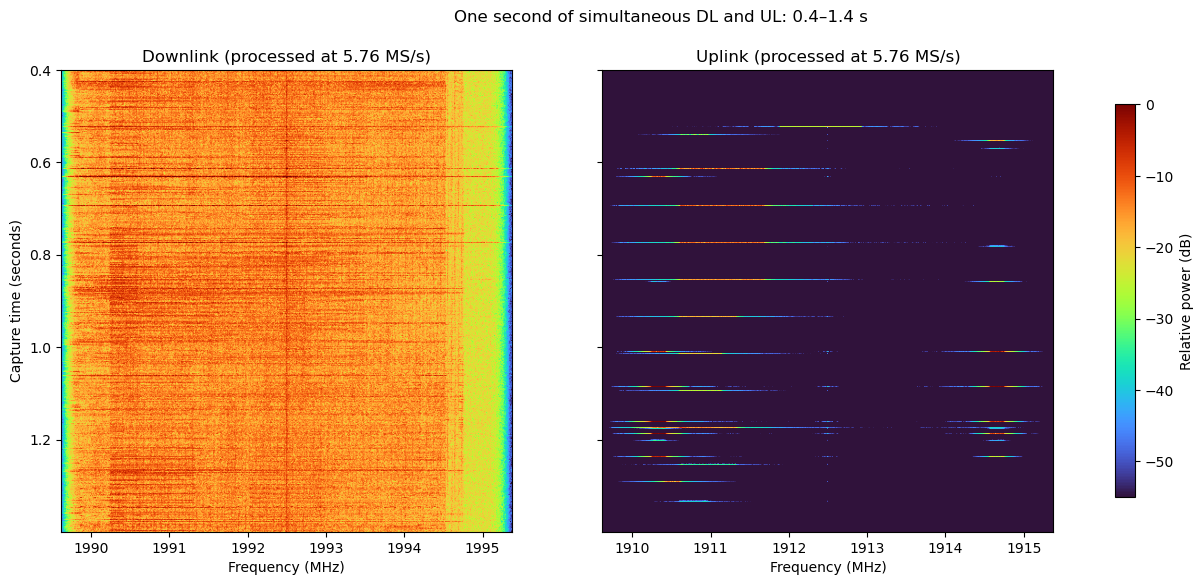

In [7]:
def one_second_waterfall(
    path: Path,
    sample_rate_hz: float,
    start_s: float,
    *,
    fft_size: int = 4096,
    rows: int = 500,
):
    source = np.memmap(path, dtype=FC32, mode="r")
    first = int(round(start_s * sample_rate_hz))
    last = min(source.size, first + int(sample_rate_hz))
    if first < 0 or last - first < fft_size:
        raise ValueError("The selected second is outside the recording")

    starts = np.linspace(first, last - fft_size, rows, dtype=np.int64)
    window = np.hanning(fft_size).astype(np.float32)
    result = np.empty((rows, fft_size), dtype=np.float32)

    for row, offset in enumerate(starts):
        samples = np.asarray(source[offset:offset + fft_size])
        spectrum = np.fft.fftshift(np.fft.fft(samples * window))
        result[row] = 10 * np.log10(np.abs(spectrum) ** 2 + 1e-20)

    # Relative power makes strong and weak structures easier to compare visually.
    result -= np.percentile(result, 99.8)
    times = starts / sample_rate_hz
    frequencies = np.fft.fftshift(np.fft.fftfreq(fft_size, 1 / sample_rate_hz))
    return times, frequencies, result


SPECTRUM_START_S = 0.4
center_frequencies_hz = {
    "Downlink": float(capture["dl_frequency_hz"]),
    "Uplink": float(capture["ul_frequency_hz"]),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for axis, (name, path) in zip(
    axes,
    (("Downlink", DL_PROCESSED_PATH), ("Uplink", UL_PROCESSED_PATH)),
):
    times, offsets, power_db = one_second_waterfall(path, DECODER_RATE_HZ, SPECTRUM_START_S)
    frequencies_mhz = (center_frequencies_hz[name] + offsets) / 1e6
    image = axis.imshow(
        power_db,
        origin="upper",
        aspect="auto",
        extent=[frequencies_mhz[0], frequencies_mhz[-1], times[-1], times[0]],
        cmap="turbo",
        vmin=-55,
        vmax=0,
    )
    axis.set_title(f"{name} (processed at 5.76 MS/s)")
    axis.set_xlabel("Frequency (MHz)")

axes[0].set_ylabel("Capture time (seconds)")
fig.colorbar(image, ax=axes, label="Relative power (dB)", shrink=0.85)
fig.suptitle(f"One second of simultaneous DL and UL: {SPECTRUM_START_S:.1f}–{SPECTRUM_START_S + 1:.1f} s")
plt.show()

### Q1. What do the downlink and uplink waterfalls show?

**Question:** What are the center frequency and LTE channel bandwidth for the downlink and uplink? Can you see both signals in the plots? Why does the downlink look more crowded while the uplink looks quieter?

**Answer:**

- **Downlink (DL):** center frequency **1992.5 MHz**; nominal LTE channel bandwidth **5 MHz**.
- **Uplink (UL):** center frequency **1912.5 MHz**; nominal LTE channel bandwidth **5 MHz**.
- Each processed waterfall spans about **5.76 MHz**, which is the decoder sample rate and includes a small amount of frequency margin around the nominal 5 MHz LTE channel.

Yes. The DL appears as a relatively persistent, broadly occupied signal, while the UL appears as shorter, intermittent bursts with more quiet space between them.

The DL looks more crowded for two reasons. First, the satellite/base-station side transmits synchronization and reference signals, broadcast information, control channels, and scheduled user data across the downlink grid. Second, in an urban area, strong terrestrial T-Mobile energy in the same or nearby PCS spectrum can overlap the displayed DL span. That terrestrial interference raises the background floor, can partially mask the weaker direct-to-cell satellite signal, and reduces the satellite link's effective SINR and decoding performance.

The UL is grant-based. A phone transmits only when scheduled, only in its assigned time-frequency resource blocks, and may be silent between transmissions. Therefore the UL waterfall is usually sparser even though an active nearby phone can produce a strong individual burst.

The waterfall is visual evidence of channel occupancy, not proof that a packet decoded correctly. Later sections confirm LTE structure with synchronization, MIB, DMRS, and CRC checks.

# Part 2 — Decode the downlink first

## 7. What is a PCI, and how does a phone camp on an LTE cell?

A **Physical Cell ID (PCI)** is the radio-layer identity that an LTE receiver obtains from the downlink synchronization signals. LTE has 504 possible PCI values, numbered 0–503. A PCI helps the phone synchronize to and distinguish a nearby cell, but it is reused across the network and is not a globally unique cell, base-station, beam, or satellite identifier.

Before a phone can exchange user traffic, it performs LTE cell selection:

1. It scans the downlink frequency and searches for the Primary and Secondary Synchronization Signals (PSS and SSS).
2. PSS/SSS provide frame timing and the PCI.
3. It decodes the PBCH/MIB to confirm that the candidate is a real LTE cell and learn essential radio parameters.
4. It reads SIB1/SIB2 and evaluates whether the cell is suitable and permitted.
5. It selects that cell and **camps** on it, meaning it monitors the cell's broadcast and control channels while idle. Camping does not necessarily mean that the phone already has an active data connection.

A precise way to say this is: **the phone camps on an LTE cell whose local physical-layer label is a PCI**. In this notebook, our passive receiver performs the same first discovery steps on the five-second DL recording: search for PSS/SSS candidates, derive their PCIs, and require a successful MIB decode before accepting a candidate as LTE.

The processed DL and UL remain sample-aligned and memory-mapped, but the waterfall alone cannot tell us which PCI is present. The next cells run the downlink search and show the PCI observed in this recording.

## 8. Search and decode the five-second downlink

**Decoder used:** this tutorial uses a patched version of **LTEsniffer**, built with the **srsRAN 4G** LTE physical-layer library, together with small decoder helpers included under `Tutorial/utils/decoder_core/`.

The tools divide the DL decode into understandable steps:

1. Search the recording for LTE PSS/SSS synchronization signals and obtain PCI candidates.
2. Decode the PBCH/MIB to confirm each candidate as a real LTE cell.
3. Align the recorded DL and UL samples to LTE subframes.
4. Run LTEsniffer on the accepted PCI to recover DL MAC/RRC messages and save them in a PCAP.
5. Extract DCI0 and RAR scheduling grants that will guide the later UL search.

The code cell below runs these steps through `TutorialPipeline`. For this teaching capture, it prepares one 4.95-second segment for the accepted PCI. Decoder work can take time on the first run, so a previously generated result is reused only after validation; the report labels that case `SKIP`.

At the end of this section we have not decoded the UL payload yet. We have decoded the DL information needed to identify the cell and determine when and where the phone was scheduled to transmit.

In [8]:
import importlib
import sys
from IPython.display import HTML, Markdown, display

# This notebook works when Jupyter starts from either the repository root or Tutorial/.
REPO_ROOT = RAW_DIR.parents[1]
if str(REPO_ROOT / "Tutorial") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "Tutorial"))

import utils.pipeline as pipeline_module
import utils.tutorial_tools as tutorial_tools_module

# Jupyter keeps imported Python modules in memory. Reload these local helpers so
# rerunning this cell picks up path or decoder changes made since the kernel began.
importlib.invalidate_caches()
importlib.reload(tutorial_tools_module)
importlib.reload(pipeline_module)

from utils.tutorial_tools import (
    decoder_paths, html_table, load_jsonl, load_manifest,
    pcap_protocol_counts, pcap_summary, plot_cell_waterfall,
    plot_crc_outcomes, plot_timing_candidates, plot_ul_grants,
    summarize_downlink, summarize_uplink,
)
from check_setup import require_setup
TutorialPipeline = pipeline_module.TutorialPipeline

PATHS = decoder_paths(REPO_ROOT)
RESULTS_DIR = PATHS["results"]

pipeline = TutorialPipeline(REPO_ROOT)
print("Processed data directory:", pipeline.processed)
print("Decoder results directory:", pipeline.results)
require_setup(TUTORIAL_DIR, require_gnuradio=False)
segment_outputs, dl_pipeline_report = pipeline.ensure_downlinks()
manifest = load_manifest(RESULTS_DIR)

display(HTML(html_table(dl_pipeline_report)))
print("All configured DL segments are ready for analysis.")

Processed data directory: /media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/processed_data
Decoder results directory: /media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/decoder_results
SKIP    processed IQ: 28,799,934 samples per channel
SKIP    manifest: /media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/decoder_results/manifest.json
SKIP    DL pci427_demo: stored PCAP and MIB-confirmed log
VERIFY  SIB1 identities: decoded from 1/1 DL PCAP segments
SKIP    PCI/MIB metadata: stored JSON summaries


stage,status,detail
processed IQ,SKIP,"28,799,934 samples per channel"
manifest,SKIP,/media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/decoder_results/manifest.json
DL pci427_demo,SKIP,stored PCAP and MIB-confirmed log
SIB1 identities,VERIFY,decoded from 1/1 DL PCAP segments
PCI/MIB metadata,SKIP,stored JSON summaries


All configured DL segments are ready for analysis.


## 9. Which PCI did we observe, and what does its MIB tell us?

**Learning goal:** understand how PSS/SSS locate an LTE cell, how the MIB confirms it, and what **FDD** means.

**Frequency Division Duplex (FDD)** uses separate frequency channels for simultaneous downlink and uplink. In this recording, the DL is centered at 1992.5 MHz and the UL at 1912.5 MHz. This differs from Time Division Duplex (TDD), where DL and UL share one carrier at different times.

For LTE FDD with normal cyclic prefix:

- PSS and SSS appear in subframes 0 and 5 and provide synchronization and the PCI.
- The PBCH appears in subframe 0 and carries the Master Information Block (MIB).
- The MIB provides essential cell settings needed before the phone can read further system information, including downlink bandwidth, system-frame timing, and PHICH configuration.

The first table reports every FDD PCI candidate found in the five-second DL recording. A candidate is accepted only if its PBCH/MIB decodes successfully. This capture contains one confirmed candidate: **PCI 427**.

The schematic then marks the standard PSS, SSS, and PBCH/MIB positions in one 10 ms LTE FDD radio frame. It is a protocol map—not a claim that these individual OFDM symbols can be identified by eye in the earlier waterfall. The final table shows what the decoder recovered from the actual MIB.

FDD PCI candidates detected in the five-second recording: [427]


PCI candidate,input time (s),CFO (Hz),peak/side ratio,frame type
427,0.0,recorded in alignment log,not reported,FDD


MIB-confirmed PCIs in the coarse passes: [427]


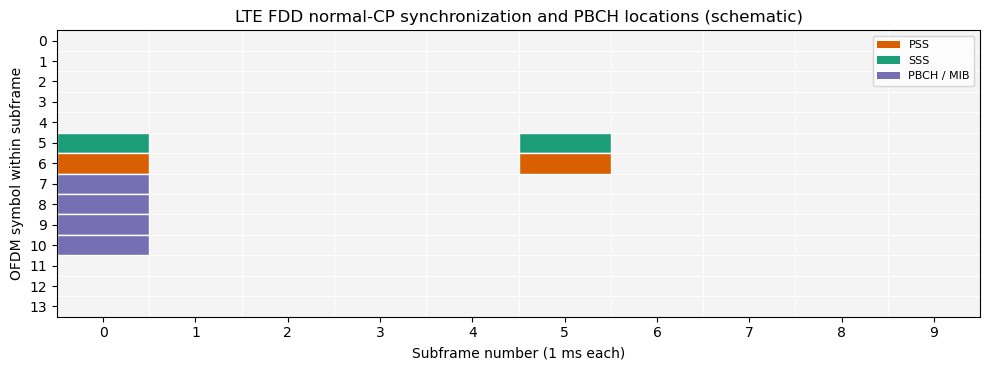

PCI,duplex mode,DL bandwidth,antenna ports,PHICH duration,PHICH resource,system frame number
427,FDD,25 PRBs (5 MHz),1,normal,1/6,304


In [9]:
cell_search = json.loads((RESULTS_DIR / "cell_search_results.json").read_text())
search_rows = []
for item in cell_search:
    if item.get("found") and item.get("frame_type") == "FDD":
        cfo_hz = item.get("cfo_hz")
        psr = item.get("psr")
        search_rows.append({
            "PCI candidate": item["pci"],
            "input time (s)": round(item.get("time_s", item.get("offset_samples", 0) / 1_920_000), 3),
            "CFO (Hz)": round(cfo_hz, 1) if cfo_hz is not None else "recorded in alignment log",
            "peak/side ratio": round(psr, 2) if psr is not None else "not reported",
            "frame type": item["frame_type"],
        })

candidate_pcis = sorted({row["PCI candidate"] for row in search_rows})
print("FDD PCI candidates detected in the five-second recording:", candidate_pcis)
display(HTML(html_table(search_rows)))

mib_results = json.loads((RESULTS_DIR / "mib_results.json").read_text())
confirmed = [row for row in mib_results if row.get("mib_found")]
print("MIB-confirmed PCIs in the coarse passes:", [row["pci"] for row in confirmed])
from matplotlib.patches import Patch, Rectangle

# Schematic LTE FDD radio frame with normal cyclic prefix:
# 10 subframes, 14 OFDM symbols per subframe.
fig, axis = plt.subplots(figsize=(10, 3.8))
for subframe in range(10):
    for symbol in range(14):
        axis.add_patch(Rectangle(
            (subframe, symbol), 1, 1,
            facecolor="#f4f4f4", edgecolor="white", linewidth=0.7,
        ))

colors = {"PSS": "#d95f02", "SSS": "#1b9e77", "PBCH / MIB": "#7570b3"}
for subframe in (0, 5):
    axis.add_patch(Rectangle((subframe, 5), 1, 1, facecolor=colors["SSS"], edgecolor="white"))
    axis.add_patch(Rectangle((subframe, 6), 1, 1, facecolor=colors["PSS"], edgecolor="white"))
for symbol in range(7, 11):
    axis.add_patch(Rectangle((0, symbol), 1, 1, facecolor=colors["PBCH / MIB"], edgecolor="white"))

axis.set_xlim(0, 10)
axis.set_ylim(14, 0)
axis.set_xticks(np.arange(10) + 0.5, labels=[str(value) for value in range(10)])
axis.set_yticks(np.arange(14) + 0.5, labels=[str(value) for value in range(14)])
axis.set_xlabel("Subframe number (1 ms each)")
axis.set_ylabel("OFDM symbol within subframe")
axis.set_title("LTE FDD normal-CP synchronization and PBCH locations (schematic)")
axis.legend(
    handles=[Patch(facecolor=color, label=label) for label, color in colors.items()],
    loc="upper right",
    fontsize=8,
)
fig.tight_layout()
plt.show()

confirmed_mib = next(row for row in mib_results if row.get("mib_found"))
bandwidth_by_prb = {6: 1.4, 15: 3, 25: 5, 50: 10, 75: 15, 100: 20}
mib_demo = [{
    "PCI": confirmed_mib["pci"],
    "duplex mode": confirmed_mib["frame_type"],
    "DL bandwidth": f"{confirmed_mib['nof_prb']} PRBs ({bandwidth_by_prb[confirmed_mib['nof_prb']]} MHz)",
    "antenna ports": confirmed_mib["nof_ports"],
    "PHICH duration": confirmed_mib["phich_length"],
    "PHICH resource": confirmed_mib["phich_resources"],
    "system frame number": confirmed_mib["sfn"],
}]
display(HTML(html_table(mib_demo)))

### Q2. Why do we need PSS, SSS, and the MIB?

**Question:** If PSS/SSS already provide the PCI, why must the decoder also read the MIB?

**Answer:** PSS/SSS provide synchronization and a PCI candidate, but PCI values are reused and correlation can produce false peaks. A successful PBCH/MIB decode proves that the timing and PCI are consistent with an LTE cell and supplies essential settings such as the 5 MHz downlink bandwidth and system-frame timing. In this capture, that process confirms PCI 427.

### How LTE organizes information in frames, subframes, and a resource grid

LTE organizes radio transmissions as a shared time-frequency map:

- One **radio frame** lasts 10 ms and contains ten 1 ms **subframes**.
- Each subframe contains two 0.5 ms **slots**.
- With normal cyclic prefix, each slot has seven OFDM symbols, so a subframe has 14 symbols.
- Frequency is divided into 15 kHz subcarriers. Twelve adjacent subcarriers form one **physical resource block (PRB)** spanning 180 kHz.
- One subcarrier during one OFDM symbol is a **resource element**, the smallest grid cell.

Different signals and channels occupy defined grid locations. A phone first finds synchronization and broadcast information, then reads downlink control instructions. Those instructions tell it which time-frequency grid cells contain its downlink data or which UL PRBs it should use for PUSCH.

A useful analogy is a spreadsheet: columns represent time, rows represent frequency, and the scheduler tells each UE which cells to read or fill. The illustration below first shows the ten subframes in a frame, then expands one DL subframe into a simplified 25-PRB × 14-symbol grid. It is a teaching diagram rather than an exact rendering of every LTE resource element.

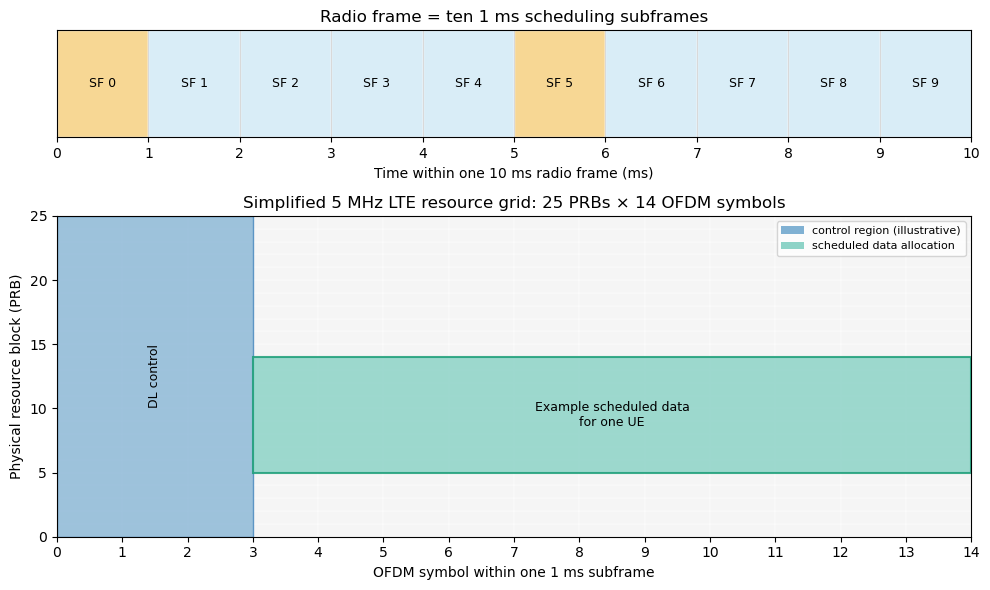

In [10]:
from matplotlib.patches import Patch, Rectangle

fig, (frame_axis, grid_axis) = plt.subplots(
    2, 1, figsize=(10, 6), gridspec_kw={"height_ratios": [1, 3]}
)

# Ten 1 ms subframes form one 10 ms LTE radio frame.
for subframe in range(10):
    color = "#d9edf7" if subframe not in (0, 5) else "#f7d794"
    frame_axis.add_patch(Rectangle((subframe, 0), 1, 1, facecolor=color, edgecolor="white"))
    frame_axis.text(subframe + 0.5, 0.5, f"SF {subframe}", ha="center", va="center", fontsize=9)
frame_axis.set_xlim(0, 10)
frame_axis.set_ylim(0, 1)
frame_axis.set_yticks([])
frame_axis.set_xticks(np.arange(11))
frame_axis.set_xlabel("Time within one 10 ms radio frame (ms)")
frame_axis.set_title("Radio frame = ten 1 ms scheduling subframes")
frame_axis.grid(axis="x", color="black", alpha=0.15)

# Simplified DL resource grid for one 5 MHz subframe.
for symbol in range(14):
    for prb in range(25):
        grid_axis.add_patch(Rectangle(
            (symbol, prb), 1, 1,
            facecolor="#f5f5f5", edgecolor="white", linewidth=0.35,
        ))

# Illustrative control region and one scheduled data allocation.
grid_axis.add_patch(Rectangle(
    (0, 0), 3, 25, facecolor="#80b1d3", alpha=0.75, edgecolor="#377eb8",
))
grid_axis.add_patch(Rectangle(
    (3, 5), 11, 9, facecolor="#8dd3c7", alpha=0.85, edgecolor="#1b9e77", linewidth=1.5,
))
grid_axis.text(1.5, 12.5, "DL control", ha="center", va="center", rotation=90, fontsize=9)
grid_axis.text(8.5, 9.5, "Example scheduled data" + chr(10) + "for one UE", ha="center", va="center", fontsize=9)

grid_axis.set_xlim(0, 14)
grid_axis.set_ylim(0, 25)
grid_axis.set_xticks(np.arange(15))
grid_axis.set_yticks(np.arange(0, 26, 5))
grid_axis.set_xlabel("OFDM symbol within one 1 ms subframe")
grid_axis.set_ylabel("Physical resource block (PRB)")
grid_axis.set_title("Simplified 5 MHz LTE resource grid: 25 PRBs × 14 OFDM symbols")
grid_axis.legend(
    handles=[
        Patch(facecolor="#80b1d3", label="control region (illustrative)"),
        Patch(facecolor="#8dd3c7", label="scheduled data allocation"),
    ],
    loc="upper right",
    fontsize=8,
)
fig.tight_layout()
plt.show()

## 10. Follow PCI 427 through the selected interval

**Learning goal:** move from finding a cell once to following its downlink over time.

After PCI 427 is confirmed, the decoder aligns LTE frames and follows the cell through a configured 4.95-second interval. The colored box in the plot shows the time-frequency region assigned to this decode.

This coverage box means that the decoder has a synchronized interval to analyze. It does not mean that every visible feature inside the box is already a decoded packet; later protocol checks determine which transmissions are valid.

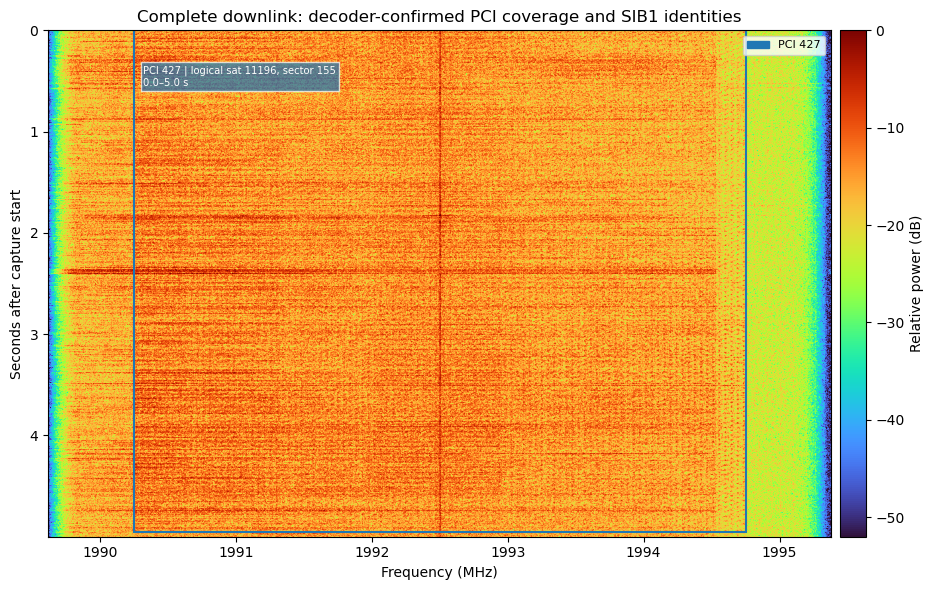

In [11]:
coverage_figure = plot_cell_waterfall(
    DL_PROCESSED_PATH,
    manifest,
    sample_rate_hz=DECODER_RATE_HZ,
    center_hz=float(capture["dl_frequency_hz"]),
)
coverage_figure.set_size_inches(10, 6)
coverage_figure.tight_layout()
plt.show()

### Q3. Does the colored PCI 427 box mean every signal inside it decoded?

**Answer:** No. The box marks the interval and bandwidth that the decoder follows after synchronization. It is a search and coverage region. Individual messages still need successful LTE channel decoding, and UL payloads later require DMRS and CRC validation.

## 11. Read the Tsat satellite identity carried by SIB1

**Learning goal:** distinguish the physical-layer PCI from Tsat's satellite and beam identifiers, then see how the bits fit together.

PCI 427 is a reusable radio-layer label used for synchronization. After synchronization, the decoder reads **System Information Block 1 (SIB1)**, which carries a 28-bit E-UTRAN Cell Identity (ECI). Tsat uses the conventional LTE split:

```text
ECI = (20-bit satellite ID << 8) | 8-bit beam/sector ID
```

For this trace:

- ECI = 2,866,331 (`0x02BBC9B`)
- Tsat satellite ID = 11,196 (`0x02BBC`)
- beam/sector ID = 155 (`0x9B`)

The diagram below separates PCI 427 from the two ECI bit fields. It shows why the PCI is used to find the radio cell, while SIB1 supplies the Tsat satellite and sector identity after decoding.

The satellite ID belongs to Tsat's identifier space. It identifies the real satellite in this network, but it should not be assumed to equal that spacecraft's NORAD catalog number unless a separate Tsat-to-NORAD mapping is available.

PCI,start (s),end (s),ECI,Tsat satellite ID,sector,DL frames
427,0.0,4.95,2866331,11196,155,611


**Identity note:** logical_satellite_id is the conventional 20-bit eNB portion of the 28-bit SIB1 ECI and, in Tsat, identifies the real-world satellite; the low 8 bits identify its beam/sector. This is a Tsat identifier, not necessarily a NORAD catalog number.

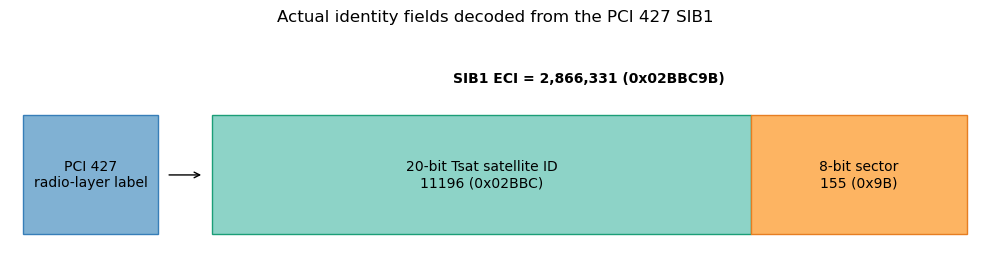

In [12]:
from matplotlib.patches import Rectangle

downlink_rows = summarize_downlink(RESULTS_DIR, manifest)
display(HTML(html_table(downlink_rows)))
display(Markdown(f"**Identity note:** {manifest['identity_note']}"))

identity_cell = manifest["cells"][0]
eci = int(identity_cell["eci_28bit"])
satellite_id = int(identity_cell["logical_satellite_id"])
sector_id = int(identity_cell["sector_id"])

fig, axis = plt.subplots(figsize=(10, 2.8))
axis.add_patch(Rectangle((-7, 0.15), 5, 0.7, facecolor="#80b1d3", edgecolor="#377eb8"))
axis.text(-4.5, 0.5, f"PCI {identity_cell['pci']}" + chr(10) + "radio-layer label", ha="center", va="center")

axis.annotate("", xy=(-0.3, 0.5), xytext=(-1.7, 0.5), arrowprops={"arrowstyle": "->"})
axis.add_patch(Rectangle((0, 0.15), 20, 0.7, facecolor="#8dd3c7", edgecolor="#1b9e77"))
axis.add_patch(Rectangle((20, 0.15), 8, 0.7, facecolor="#fdb462", edgecolor="#e67e22"))
axis.text(10, 0.5, "20-bit Tsat satellite ID" + chr(10) + f"{satellite_id} (0x{satellite_id:05X})", ha="center", va="center")
axis.text(24, 0.5, "8-bit sector" + chr(10) + f"{sector_id} (0x{sector_id:02X})", ha="center", va="center")
axis.text(14, 1.02, f"SIB1 ECI = {eci:,} (0x{eci:07X})", ha="center", va="bottom", fontweight="bold")

axis.set_xlim(-7.5, 28.5)
axis.set_ylim(0, 1.35)
axis.axis("off")
axis.set_title("Actual identity fields decoded from the PCI 427 SIB1")
fig.tight_layout()
plt.show()

### Q4. Are PCI 427 and the Tsat satellite ID the same identifier?

**Answer:** No. PCI 427 is a reusable physical-layer label used for synchronization. SIB1 carries a 28-bit ECI whose upper 20 bits identify the real-world Tsat satellite and whose lower 8 bits identify its beam or sector. The Tsat satellite ID is a real satellite identifier, although it is not necessarily the same numeric identifier used by the NORAD catalog.

## 12. Follow one radio frame upward through the LTE protocol layers

**Learning goal:** connect energy in the spectrum to the nested protocol information shown by Wireshark.

A decoded radio transmission can contain several layers, much like an envelope inside another envelope:

- **MAC-LTE** describes radio scheduling and transport blocks.
- **RLC** segments, reorders, and reassembles data for radio delivery.
- **PDCP** handles functions such as header compression and security.
- **RRC** controls the radio connection and carries messages such as SIB1/SIB2 and connection setup.
- **NAS-EPS** carries core-network procedures such as attach, authentication, and security management.

SIB1 identifies the cell and Tsat satellite/sector. SIB2 provides common radio-access parameters. Dedicated RRC messages configure a particular UE. NAS then handles mobility and core-network signaling when those messages are visible and decryptable.

One MAC frame can contain a higher-layer message, so the protocol counts below overlap; they should not be added together as separate packets. The bar chart uses the actual PCI 427 DL PCAP to show which layers Wireshark could dissect in this five-second trace.

segment,PCI,MAC-LTE,RLC,PDCP,RRC,NAS-EPS
pci427_demo,427,611,245,185,441,45


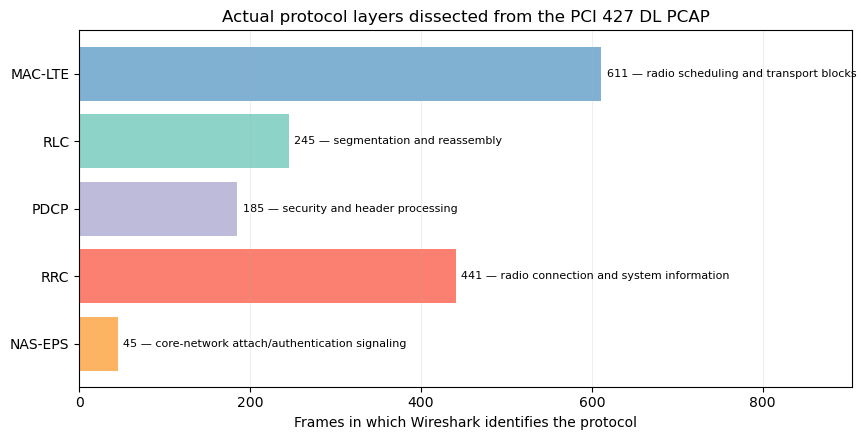

In [13]:
protocol_rows = []
trace_counts = None
for cell in manifest["cells"]:
    counts = pcap_protocol_counts(RESULTS_DIR / cell["dl_pcap"])
    if trace_counts is None:
        trace_counts = counts
    protocol_rows.append({
        "segment": cell["label"],
        "PCI": cell["pci"],
        "MAC-LTE": counts.get("mac-lte", 0),
        "RLC": counts.get("rlc-lte", 0),
        "PDCP": counts.get("pdcp-lte", 0),
        "RRC": counts.get("lte_rrc", 0),
        "NAS-EPS": counts.get("nas-eps", 0),
    })
display(HTML(html_table(protocol_rows)))

layer_definitions = [
    ("MAC-LTE", "mac-lte", "radio scheduling and transport blocks"),
    ("RLC", "rlc-lte", "segmentation and reassembly"),
    ("PDCP", "pdcp-lte", "security and header processing"),
    ("RRC", "lte_rrc", "radio connection and system information"),
    ("NAS-EPS", "nas-eps", "core-network attach/authentication signaling"),
]
labels = [item[0] for item in layer_definitions]
values = [trace_counts.get(item[1], 0) for item in layer_definitions]

fig, axis = plt.subplots(figsize=(9, 4.5))
positions = np.arange(len(labels))
bars = axis.barh(positions, values, color=["#80b1d3", "#8dd3c7", "#bebada", "#fb8072", "#fdb462"])
axis.set_yticks(positions, labels)
axis.invert_yaxis()
axis.set_xlabel("Frames in which Wireshark identifies the protocol")
axis.set_title("Actual protocol layers dissected from the PCI 427 DL PCAP")
for bar, value, (_, _, meaning) in zip(bars, values, layer_definitions):
    axis.text(value + max(values) * 0.01, bar.get_y() + bar.get_height() / 2, f"{value} — {meaning}", va="center", fontsize=8)
axis.set_xlim(0, max(values) * 1.48)
axis.grid(axis="x", alpha=0.2)
fig.tight_layout()
plt.show()

### Q4b. Why are there fewer RRC or NAS frames than MAC-LTE frames?

**Answer:** MAC is the radio transport layer, so nearly every decoded LTE radio frame appears there. Only some MAC payloads carry RLC/PDCP data, and only some of those contain RRC or NAS signaling. The layers are nested, so one frame may be counted at several levels. A smaller NAS count means NAS messages are less frequent or not always visible—not that the other MAC frames are invalid.

# Part 3 — Use downlink instructions to recover uplink packets

The uplink is harder to find because a phone does not transmit the same continuous synchronization signals used for downlink cell search. Instead, it sends short bursts only in resources assigned by the network.

The decoded DL gives us a focused search plan:

```text
DL scheduling grant
  → expected UL time and frequency resources
  → timing and frequency correction
  → PUSCH reference-signal (DMRS) match
  → payload decoding
  → transport-block CRC
```

PUSCH is the LTE Physical Uplink Shared Channel used for scheduled phone data. DMRS helps verify the expected uplink waveform and estimate the channel; the CRC is the final check that the recovered payload bits are internally consistent. A bright burst or a strong DMRS match alone is not enough to claim a valid packet.

In [14]:
# Part 3 is self-initializing: it can be run after a kernel restart without
# depending on Python variables left behind by Parts 1 and 2.
from pathlib import Path
import importlib
import json
import os
import sys

import matplotlib.pyplot as plt
from IPython.display import HTML, display

tutorial_candidates = (
    [Path(os.environ["LTE_TUTORIAL_DIR"])] if "LTE_TUTORIAL_DIR" in os.environ else []
) + [Path.cwd(), Path.cwd() / "Tutorial"]
TUTORIAL_DIR = next(
    (path.resolve() for path in tutorial_candidates if (path / "raw_data/capture.json").is_file()),
    None,
)
if TUTORIAL_DIR is None:
    raise FileNotFoundError(
        "Cannot find Tutorial/raw_data/capture.json. Start Jupyter from the repository "
        "root or Tutorial directory, or set LTE_TUTORIAL_DIR."
    )
REPO_ROOT = TUTORIAL_DIR.parent
RAW_DIR = TUTORIAL_DIR / "raw_data"
PROCESSED_DIR = TUTORIAL_DIR / "processed_data"
RESULTS_DIR = TUTORIAL_DIR / "decoder_results"
DL_PROCESSED_PATH = PROCESSED_DIR / "downlink_5p76Msps.fc32"
UL_PROCESSED_PATH = PROCESSED_DIR / "uplink_5p76Msps.fc32"
DECODER_RATE_HZ = 5_760_000
capture = json.loads((RAW_DIR / "capture.json").read_text())["capture"]

if str(TUTORIAL_DIR) not in sys.path:
    sys.path.insert(0, str(TUTORIAL_DIR))
import utils.pipeline as pipeline_module
import utils.tutorial_tools as tutorial_tools_module
importlib.invalidate_caches()
importlib.reload(pipeline_module)
importlib.reload(tutorial_tools_module)
from utils.pipeline import TutorialPipeline
from utils.tutorial_tools import (
    html_table, load_jsonl, load_manifest, pcap_protocol_counts, pcap_summary,
    plot_crc_outcomes, plot_timing_candidates, plot_ul_grants, summarize_uplink,
)
from check_setup import require_setup

require_setup(TUTORIAL_DIR, require_gnuradio=False)
pipeline = TutorialPipeline(REPO_ROOT)
segment_outputs, _ = pipeline.ensure_downlinks()
manifest = load_manifest(RESULTS_DIR)

# This is the expensive stage only when validated UL outputs are absent.
final_pcap, pipeline_report = pipeline.ensure_uplinks(segment_outputs)
display(HTML(html_table(pipeline_report)))
print("Final stored PCAPNG:", final_pcap)

SKIP    processed IQ: 28,799,934 samples per channel
SKIP    manifest: /media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/decoder_results/manifest.json
SKIP    DL pci427_demo: stored PCAP and MIB-confirmed log
VERIFY  SIB1 identities: decoded from 1/1 DL PCAP segments
SKIP    PCI/MIB metadata: stored JSON summaries
SKIP    UL pci427_demo: stored acquisition, attempts, and CRC output
SKIP    final PCAPNG: /media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/decoder_results/pcap/all_cells_complete_dl_ul_with_mib.pcapng


stage,status,detail
processed IQ,SKIP,"28,799,934 samples per channel"
manifest,SKIP,/media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/decoder_results/manifest.json
DL pci427_demo,SKIP,stored PCAP and MIB-confirmed log
SIB1 identities,VERIFY,decoded from 1/1 DL PCAP segments
PCI/MIB metadata,SKIP,stored JSON summaries
UL pci427_demo,SKIP,"stored acquisition, attempts, and CRC output"
final PCAPNG,SKIP,/media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/decoder_results/pcap/all_cells_complete_dl_ul_with_mib.pcapng


Final stored PCAPNG: /media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/decoder_results/pcap/all_cells_complete_dl_ul_with_mib.pcapng


## 13. Turn one downlink grant into an uplink map location

**Learning goal:** read the fields of a real scheduling grant and use them to locate a phone transmission in the LTE grid.

A **grant** is a compact control instruction decoded from DCI0 or a Random Access Response (RAR). It does not contain the phone's payload. It tells the UE how to construct a future PUSCH transmission.

Important fields in this notebook are:

- **`burst_sf`**: the decoder's zero-based, file-relative UL subframe index. Because one subframe is 1 ms, `burst_sf=4267` points to approximately 4.267 s after this segment's start. This is a tutorial/decoder coordinate, not a field transmitted with that name over the air.
- **RNTI**: a 16-bit temporary radio identifier used to address a UE or radio procedure within the cell. It is not a phone number, IMSI, or permanent device identity.
- **PRB start/count**: the first frequency block and the number of consecutive 180 kHz PRBs assigned to the UE.
- **MCS**: the modulation and coding scheme index, which controls how aggressively bits are packed and protected.
- **TBS**: transport-block size—the number of payload bits expected after channel decoding.
- **RAR**: whether the allocation came from the random-access procedure rather than a normal DCI0 grant.

The worked example below comes from an actual CRC-valid PCI 427 packet. It first translates the grant into plain language, then draws the exact scheduled PRB rectangle and its PUSCH DMRS symbols. A second table lists several grants so students can see that the scheduler changes UE, time, and allocation from one transmission to another.

field,actual value,meaning in this example
burst_sf,4267,"search UL subframe 4267, about 4.267 s after segment start"
RNTI,258 (0x0102),temporary radio address for this UE context
PRB allocation,2–3 (2 PRBs),360 kHz of scheduled UL bandwidth
MCS / modulation,3 / QPSK,selects modulation and channel-coding behavior
TBS,104 bits (13 bytes),expected decoded transport-block length
RAR,no,"normal DCI0 grant, not a random-access allocation"


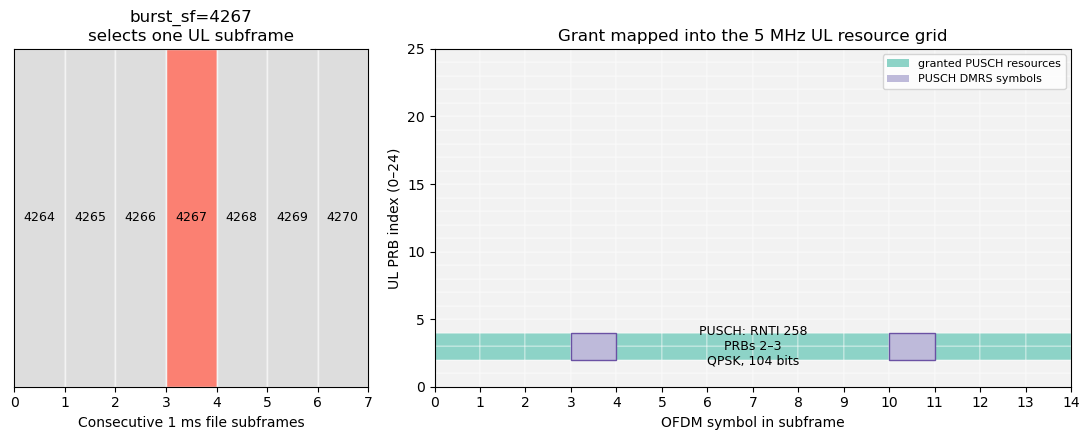

burst_sf,RNTI,PRBs,MCS,TBS bits,RAR
601,258 (0x0102),2–7,9,936,False
678,256 (0x0100),2–7,9,936,False
680,256 (0x0100),2–7,9,936,False
758,256 (0x0100),2–7,9,936,False
760,256 (0x0100),2–7,9,936,False
761,258 (0x0102),2–7,6,600,False
838,256 (0x0100),2–7,9,936,False
840,256 (0x0100),2–7,9,936,False
841,258 (0x0102),2–7,5,504,False
921,258 (0x0102),2–5,5,328,False


In [15]:
import numpy as np
from matplotlib.patches import Patch, Rectangle

selected_cell = next(cell for cell in manifest["cells"] if cell["label"] == "pci427_demo")
selected_ul_dir = RESULTS_DIR / "uplink" / selected_cell["ul_result"]
acquisitions = load_jsonl(selected_ul_dir / "grant_directed_acquisition.jsonl")
crc_valid_rows = load_jsonl(selected_ul_dir / "crc_valid_ul.jsonl")
worked_packet = max(
    crc_valid_rows, key=lambda row: abs(float(row["physical"]["lag_us"]))
)
worked_grant = worked_packet["grant"]

burst_sf = int(worked_packet["burst_sf"])
prb_start = int(worked_grant["prb_tilde0"])
prb_count = int(worked_grant["len_prb"])
prb_end = prb_start + prb_count - 1
rnti = int(worked_grant["rnti"])
tbs_bits = int(worked_grant["tbs"])
modulation = worked_packet["decode"]["mod"].upper()

grant_explanation = [
    {
        "field": "burst_sf",
        "actual value": burst_sf,
        "meaning in this example": f"search UL subframe {burst_sf}, about {burst_sf / 1000:.3f} s after segment start",
    },
    {
        "field": "RNTI",
        "actual value": f"{rnti} (0x{rnti:04X})",
        "meaning in this example": "temporary radio address for this UE context",
    },
    {
        "field": "PRB allocation",
        "actual value": f"{prb_start}–{prb_end} ({prb_count} PRBs)",
        "meaning in this example": f"{prb_count * 180} kHz of scheduled UL bandwidth",
    },
    {
        "field": "MCS / modulation",
        "actual value": f"{worked_grant['mcs']} / {modulation}",
        "meaning in this example": "selects modulation and channel-coding behavior",
    },
    {
        "field": "TBS",
        "actual value": f"{tbs_bits} bits ({tbs_bits // 8} bytes)",
        "meaning in this example": "expected decoded transport-block length",
    },
    {
        "field": "RAR",
        "actual value": "yes" if worked_grant["rar"] else "no",
        "meaning in this example": "normal DCI0 grant, not a random-access allocation",
    },
]
display(HTML(html_table(grant_explanation)))

fig, (time_axis, resource_axis) = plt.subplots(
    1, 2, figsize=(11, 4.5), gridspec_kw={"width_ratios": [1, 1.8]}
)

# Show burst_sf as one selected 1 ms cell in the aligned file timeline.
timeline_start = burst_sf - 3
for index in range(7):
    sf = timeline_start + index
    selected = sf == burst_sf
    time_axis.add_patch(Rectangle(
        (index, 0), 1, 1,
        facecolor="#fb8072" if selected else "#dddddd",
        edgecolor="white",
    ))
    time_axis.text(index + 0.5, 0.5, str(sf), ha="center", va="center", fontsize=9)
time_axis.set_xlim(0, 7)
time_axis.set_ylim(0, 1)
time_axis.set_xticks(np.arange(8))
time_axis.set_yticks([])
time_axis.set_xlabel("Consecutive 1 ms file subframes")
time_axis.set_title(f"burst_sf={burst_sf}" + chr(10) + "selects one UL subframe")
time_axis.grid(axis="x", alpha=0.15)

# Show the granted PRBs across the 14 OFDM symbols of that subframe.
for symbol in range(14):
    for prb in range(25):
        in_grant = prb_start <= prb <= prb_end
        resource_axis.add_patch(Rectangle(
            (symbol, prb), 1, 1,
            facecolor="#8dd3c7" if in_grant else "#f2f2f2",
            edgecolor="white",
            linewidth=0.35,
        ))
for dmrs_symbol in (3, 10):
    resource_axis.add_patch(Rectangle(
        (dmrs_symbol, prb_start), 1, prb_count,
        facecolor="#bebada", edgecolor="#6a51a3", linewidth=1.0,
    ))

resource_axis.text(
    7, prb_start + prb_count / 2,
    f"PUSCH: RNTI {rnti}" + chr(10) + f"PRBs {prb_start}–{prb_end}" + chr(10) + f"{modulation}, {tbs_bits} bits",
    ha="center", va="center", fontsize=9,
)
resource_axis.set_xlim(0, 14)
resource_axis.set_ylim(0, 25)
resource_axis.set_xticks(np.arange(15))
resource_axis.set_yticks(np.arange(0, 26, 5))
resource_axis.set_xlabel("OFDM symbol in subframe")
resource_axis.set_ylabel("UL PRB index (0–24)")
resource_axis.set_title("Grant mapped into the 5 MHz UL resource grid")
resource_axis.legend(
    handles=[
        Patch(facecolor="#8dd3c7", label="granted PUSCH resources"),
        Patch(facecolor="#bebada", label="PUSCH DMRS symbols"),
    ],
    loc="upper right",
    fontsize=8,
)
fig.tight_layout()
plt.show()

grant_rows = []
for item in acquisitions[:10]:
    grant = item["grant"]
    grant_rows.append({
        "burst_sf": item["burst"]["burst_sf"],
        "RNTI": f"{grant['rnti']} (0x{grant['rnti']:04X})",
        "PRBs": f"{grant['prb_tilde0']}–{grant['prb_tilde0'] + grant['len_prb'] - 1}",
        "MCS": grant["mcs"],
        "TBS bits": grant["tbs"],
        "RAR": bool(grant["rar"]),
    })
display(HTML(html_table(grant_rows)))

## 14. Compare grant rectangles with the recorded uplink

**Learning goal:** connect the scheduler's grid coordinates to energy measured by the X300.

The plot below focuses on the worked grant so its true 1 ms by 1.08 MHz allocation is large enough to inspect:

- Time is `segment start + burst_sf × 1 ms`.
- Frequency starts at the lower edge of the 25-PRB LTE channel and advances by 180 kHz per PRB.
- Rectangle width is `PRB count × 180 kHz`.
- Rectangle height is one 1 ms subframe.

For the maximum-offset worked example, `burst_sf=4267` places the expected rectangle near 4.267 s. PRBs 2–3 occupy 0.36 MHz, approximately 1910.61–1910.97 MHz in this 1912.5 MHz-centered UL channel.

The figure uses **two copies of the same short recorded UL interval** around the worked example. The first shows only the received signal. The second compares the lightly filled cyan grant-predicted window with the dashed green window where the CRC-valid PUSCH was actually found after timing search. This packet has the largest-magnitude valid timing offset in the trace: −416.319 µs.

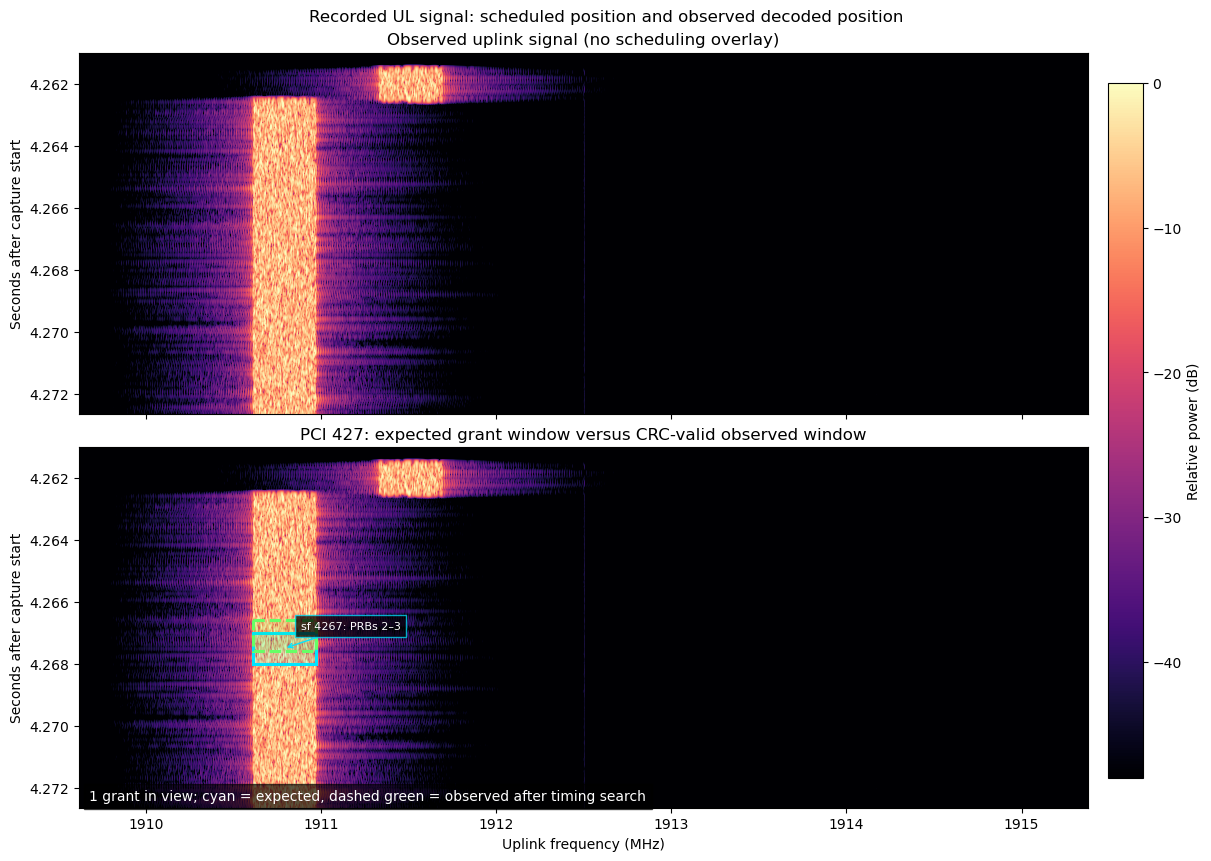

In [16]:
worked_acquisitions = [
    row for row in acquisitions
    if int(row["burst"]["burst_sf"]) == burst_sf
    and all(
        int(row["grant"][key]) == int(worked_grant[key])
        for key in ("rnti", "prb_tilde0", "len_prb", "mcs", "tbs")
    )
]
worked_event_s = (
    float(selected_cell["start_s"])
    + float(selected_cell.get("aligned_start_offset_s", 0.0))
    + burst_sf / 1000.0
)
plot_ul_grants(
    UL_PROCESSED_PATH,
    worked_acquisitions,
    selected_cell,
    start_s=worked_event_s - 0.006,
    duration_s=0.012,
    observed_rows=crc_valid_rows,
    sample_rate_hz=DECODER_RATE_HZ,
    center_hz=float(capture["ul_frequency_hz"]),
)
plt.show()

### Q5. Why use a DL grant instead of searching every bright UL burst?

**Answer:** A grant predicts the phone's UL subframe and PRB allocation, reducing a large blind search to a small time-frequency region. Brightness alone is ambiguous because interference, control signals, or another UE can also produce energy. The grant supplies context; DMRS and CRC provide stronger validation.

## 15. Correct timing and frequency, then check the PUSCH reference signal

**Learning goal:** understand timing advance, carrier-frequency offset, and DMRS using a successful packet from this trace.

- **Timing advance (TA)** tells the phone to transmit early enough for its waveform to reach the satellite in the correct LTE subframe.
- **Observed timing offset** is where our nearby X300 sees that waveform relative to the grant-derived position. It differs from what the satellite sees because the receiver is in a different location.
- **Carrier-frequency offset (CFO)** is a small frequency mismatch caused by oscillator error and motion; it must be corrected before coherent decoding.
- **DMRS coherence** measures how closely the received PUSCH reference signal matches the LTE sequence expected from the grant.

For the maximum-offset CRC-valid packet, the selected candidate is 416.319 microseconds early, uses a −2296.670 Hz frequency correction, and has DMRS coherence 0.999858. All 243 CRC-valid packets in this recording have negative timing offsets, ranging from −401.215 to −416.319 µs. The table and scatter plot below point to these quantities in the real trace. Green points are timing/CFO candidates that later produced CRC-valid payloads. The common early direction is consistent with the X300 being close to the UE while the UE advances its transmission for the satellite path, but this residual offset also includes alignment choices and is not a standalone distance measurement.

concept,actual trace value,how it is used
observed timing offset,-416.319 µs,shift from the grant-derived position to the samples seen by the X300
CFO correction,-2296.670 Hz,remove carrier rotation before demodulation
DMRS coherence,0.999858,compare the received reference sequence with the expected PUSCH DMRS
estimated SNR,34.143 dB,describe signal quality for this selected candidate


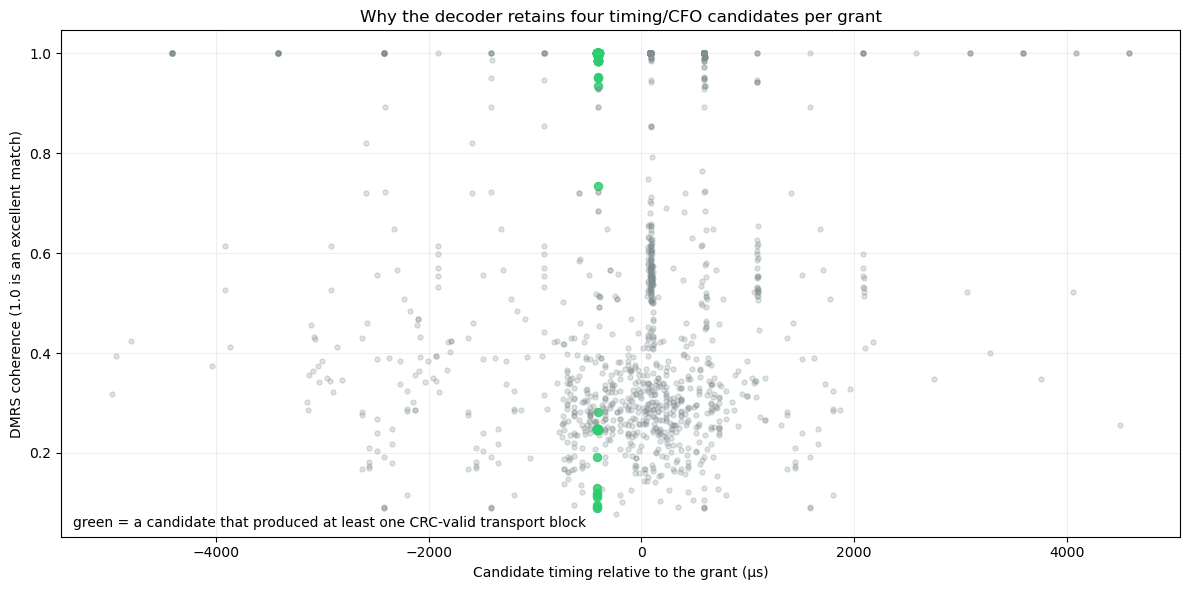

In [17]:
crc_valid_rows = load_jsonl(selected_ul_dir / "crc_valid_ul.jsonl")
timing_example = worked_packet
physical = timing_example["physical"]

timing_terms = [
    {
        "concept": "observed timing offset",
        "actual trace value": f"{physical['lag_us']:.3f} µs",
        "how it is used": "shift from the grant-derived position to the samples seen by the X300",
    },
    {
        "concept": "CFO correction",
        "actual trace value": f"{physical['correction_hz']:.3f} Hz",
        "how it is used": "remove carrier rotation before demodulation",
    },
    {
        "concept": "DMRS coherence",
        "actual trace value": f"{physical['coherence']:.6f}",
        "how it is used": "compare the received reference sequence with the expected PUSCH DMRS",
    },
    {
        "concept": "estimated SNR",
        "actual trace value": f"{physical['snr_db']:.3f} dB",
        "how it is used": "describe signal quality for this selected candidate",
    },
]
display(HTML(html_table(timing_terms)))
plot_timing_candidates(acquisitions, crc_valid_rows)
plt.show()

## 16. Decode the payload and require a valid CRC

**Learning goal:** follow the narrowing process from scheduling instructions to trusted payload bits.

After timing/CFO and DMRS acquisition, the decoder still needs:

- **MCS**, which selects modulation and coding behavior.
- **TBS**, the expected number of bits in the transport block.
- **RRC configuration**, the UE-specific radio settings decoded from the DL.
- **UCI**, such as ACK, CQI, and RI, which may be multiplexed with PUSCH and change the bit layout.
- **CRC**, the final integrity check over the recovered transport block.

The trace contains 282 unique DL grants. The decoder examines multiple physical candidates per grant, producing 581 DMRS-accepted candidates and 332 payload-decode attempts. Of those attempts, 243 produce CRC-valid UL packets. Candidate counts are not a simple funnel—one grant can produce several timing/DMRS candidates—but only CRC-passing payloads enter the trusted PCAP.

The stage table and plot below use these actual trace counts. For the maximum-offset worked packet, MCS 3, QPSK, and TBS 104 bits lead to a 13-byte CRC-valid transport block.

PCI,segment,unique DL grants,DMRS candidates,decode attempts,CRC passed
427,pci427_demo,282,581,332,243


Total CRC-valid UL packets: 243


stage,count,student interpretation
unique DL grants,282,distinct scheduling instructions recovered from the DL
timing-search tasks,1115,candidate windows tested; several can come from one grant
DMRS-accepted candidates,581,candidates with plausible PUSCH reference-signal structure
payload-decode attempts,332,candidates for which modulation/coding hypotheses were decoded
CRC-valid UL packets,243,transport blocks accepted into the trusted result


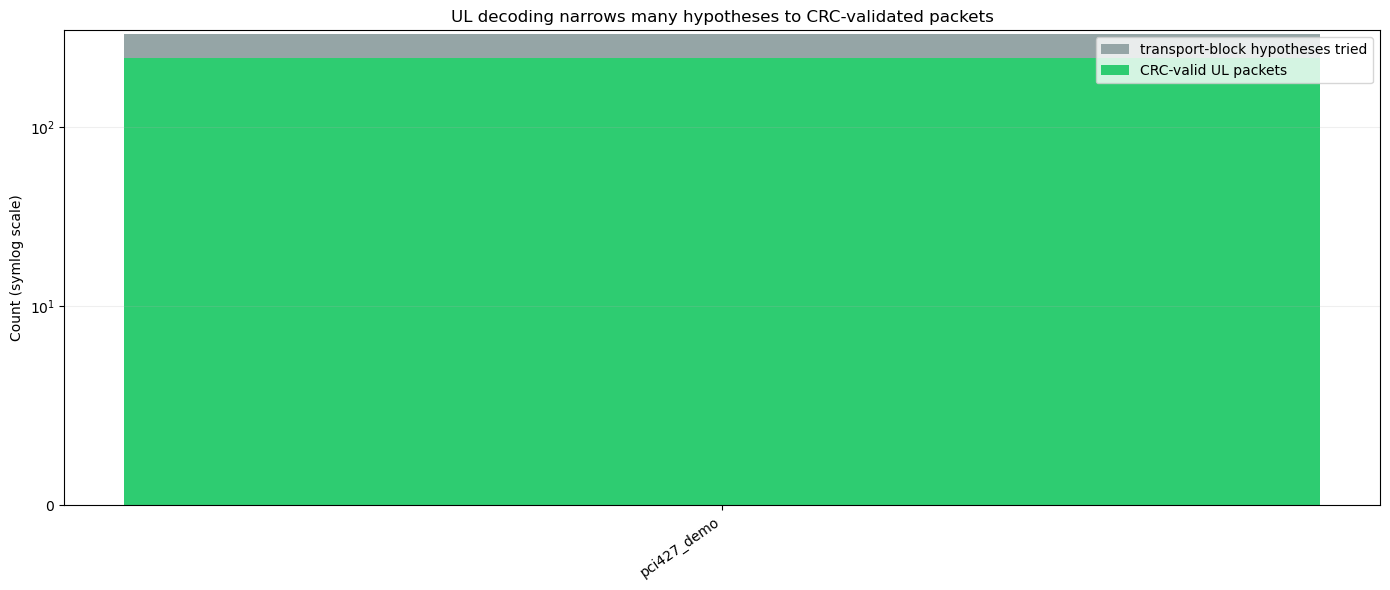

In [18]:
uplink_rows = summarize_uplink(RESULTS_DIR, manifest)
display(HTML(html_table(uplink_rows)))
print("Total CRC-valid UL packets:", sum(row["CRC passed"] for row in uplink_rows))

ul_summary = json.loads((selected_ul_dir / "summary.json").read_text())
validation_stages = [
    {
        "stage": "unique DL grants",
        "count": ul_summary["unique_dl_grants"],
        "student interpretation": "distinct scheduling instructions recovered from the DL",
    },
    {
        "stage": "timing-search tasks",
        "count": ul_summary["grant_directed_timing_tasks"],
        "student interpretation": "candidate windows tested; several can come from one grant",
    },
    {
        "stage": "DMRS-accepted candidates",
        "count": ul_summary["dmrs_accepted"],
        "student interpretation": "candidates with plausible PUSCH reference-signal structure",
    },
    {
        "stage": "payload-decode attempts",
        "count": ul_summary["decode_attempts"],
        "student interpretation": "candidates for which modulation/coding hypotheses were decoded",
    },
    {
        "stage": "CRC-valid UL packets",
        "count": ul_summary["crc_valid_packets"],
        "student interpretation": "transport blocks accepted into the trusted result",
    },
]
display(HTML(html_table(validation_stages)))
plot_crc_outcomes(uplink_rows)
plt.show()

### Q6. Why is a strong DMRS match not the final answer?

**Answer:** DMRS confirms the expected PUSCH reference structure and helps estimate timing, frequency offset, and the radio channel. Payload bits can still be wrong if coding or UCI settings are incorrect. The transport-block CRC is therefore required before an UL payload is accepted.

### Worked example: inspect one CRC-valid UL result

The table below connects the stages for one successful packet: the original grant, selected timing/CFO and DMRS candidate, modulation and transport-block settings, measured signal quality, CRC result, and a short payload prefix.

The full JSONL record preserves this audit trail. Only a short hexadecimal prefix is displayed here; Wireshark is used later to interpret the complete payload as LTE protocol data.

In [19]:
example = worked_packet
example_row = {
    "PCI": example["pci"],
    "RNTI": example["grant"]["rnti"],
    "burst subframe": example["burst_sf"],
    "PRBs": f"{example['grant']['prb_tilde0']} + {example['grant']['len_prb']}",
    "MCS": example["grant"]["mcs"],
    "modulation": example["decode"]["mod"],
    "timing (µs)": example["physical"]["lag_us"],
    "DMRS coherence": example["physical"]["coherence"],
    "SNR (dB)": example["decode"]["snr_db"],
    "CRC": example["decode"]["crc"],
    "payload prefix": example["decode"]["payload_hex"][:32] + "…",
}
display(HTML(html_table([example_row])))

PCI,RNTI,burst subframe,PRBs,MCS,modulation,timing (µs),DMRS coherence,SNR (dB),CRC,payload prefix
427,258,4267,2 + 2,3,qpsk,-416.319,0.999858,34.143,True,03984dd34ab51ca872fc42a168…


## 17. Check the pipeline status

**Learning goal:** distinguish a newly generated result from a validated result reused from an earlier run.

The report uses `CREATE` when this run generated and stored an artifact. It uses `SKIP` when the artifact already existed and passed its validation checks. Both statuses can represent a successful stage.

This makes the notebook restartable and lets students repeat later analysis without rerunning every expensive decoder step.

In [20]:
display(HTML(html_table(pipeline_report)))
print("Pipeline report stored at:", RESULTS_DIR / "pipeline_report.json")

stage,status,detail
processed IQ,SKIP,"28,799,934 samples per channel"
manifest,SKIP,/media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/decoder_results/manifest.json
DL pci427_demo,SKIP,stored PCAP and MIB-confirmed log
SIB1 identities,VERIFY,decoded from 1/1 DL PCAP segments
PCI/MIB metadata,SKIP,stored JSON summaries
UL pci427_demo,SKIP,"stored acquisition, attempts, and CRC output"
final PCAPNG,SKIP,/media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/decoder_results/pcap/all_cells_complete_dl_ul_with_mib.pcapng


Pipeline report stored at: /media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/decoder_results/pipeline_report.json


# Part 4 — Build a packet trace from validated results

The radio-processing stages have now produced confirmed DL frames and CRC-valid UL transport blocks. The packaging stage places them into PCAP/PCAPNG files so their timing, direction, and LTE protocol layers can be inspected together in Wireshark.

For the selected five-second interval, packaging:

- assigns capture-relative timestamps;
- preserves uplink versus downlink direction;
- gives each `(PCI, RNTI)` pair a separate MAC-LTE UE context;
- includes reconstructed MIB records and decoded DL activity;
- includes only UL transport blocks whose CRC passed.

Timing advance helps locate the UL waveform, but it does not change the final packet timestamp to the signal's arrival time at the satellite.

In [21]:
pcap_dir = RESULTS_DIR / "pcap"
pcap_files = [
    pcap_dir / "all_cells_complete_dl_ul_with_mib.pcapng",
    pcap_dir / "all_cells_full_dl_plus_crc_valid_ul.pcap",
    pcap_dir / "all_cells_crc_valid_ul_only.pcap",
]
display(HTML(html_table([pcap_summary(path) for path in pcap_files])))

file,bytes,frames,downlink MAC frames,uplink MAC frames,MAC-LTE frames,RRC frames,NAS-EPS frames,RLC-LTE frames
all_cells_complete_dl_ul_with_mib.pcapng,63500,855,611,243,854,450,53,265
all_cells_full_dl_plus_crc_valid_ul.pcap,47994,854,611,243,854,450,52,265
all_cells_crc_valid_ul_only.pcap,12016,243,0,243,243,8,6,20


## 18. Inspect the final result in Wireshark

**Learning goal:** use protocol filters to move from the combined radio trace to specific LTE messages.

Open `all_cells_complete_dl_ul_with_mib.pcapng` for the combined trace. Useful Wireshark display filters include:

```text
mac-lte.direction == 0        # uplink
mac-lte.direction == 1        # downlink
lte-rrc                       # RRC messages such as SIB and connection control
nas-eps                       # NAS signaling when visible/decryptable
mac-lte.crc-status == 1       # CRC-valid frames when this field is present
```

The reference run for this interval contains 243 CRC-valid PCI 427 UL transport blocks. Valid reruns have recovered at least 241 and may retain one additional adjacent valid grant, so the pipeline validates a minimum of 241 rather than requiring one exact count. The generated summary reports the count for the current run.

In [22]:
final_pcap = pcap_dir / "all_cells_complete_dl_ul_with_mib.pcapng"
print("Final PCAPNG:", final_pcap)
print("Exists:", final_pcap.is_file())
print("Size:", f"{final_pcap.stat().st_size / 1e6:.3f} MB")
print("Wireshark protocol counts:", pcap_protocol_counts(final_pcap).most_common(10))

Final PCAPNG: /media/morty/X10 Pro/Desktop-backup/nids-leo/Tutorial/decoder_results/pcap/all_cells_complete_dl_ul_with_mib.pcapng
Exists: True
Size: 0.064 MB
Wireshark protocol counts: [('user_dlt', 855), ('mac-lte-framed', 854), ('mac-lte', 854), ('lte_rrc', 450), ('rlc-lte', 265), ('pdcp-lte', 194), ('nas-eps', 53), ('ipcp', 1)]


## 19. Evidence checklist and limits of the result

The tutorial uses a chain of increasingly strong evidence:

- PSS/SSS correlation proposes a PCI and timing.
- A decoded MIB confirms the candidate as an LTE cell.
- SIB1 maps the cell to a real-world Tsat satellite ID and beam/sector.
- A DL grant predicts a phone's UL time and PRB allocation.
- DMRS checks the expected PUSCH structure and refines timing/CFO.
- A passing transport-block CRC validates the recovered UL payload.
- PCAP packaging preserves the validated results for protocol inspection.

Important limits remain:

- A bright waterfall feature alone is not called a packet.
- A Tsat satellite ID should not be assumed to equal a NORAD catalog number without a separate mapping.
- Encrypted user-plane data or protected signaling remains encrypted; this tutorial does not claim plaintext without the required keys.